In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score
%config InlineBackend.figure_format = 'svg'

In [2]:
path = r"..\\"
df = pd.read_csv(path+'Bank_Customer_Churn_Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
df['gender'] = df['gender'].map({'Male':0, 'Female':1})
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender                int64
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [6]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [7]:
df.describe()

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,0.454300,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,0.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.shape

(10000, 12)

In [9]:
#the duplicated data entries
df.duplicated().sum()

0

In [10]:
df = df.drop_duplicates()
df = df.select_dtypes(include=['int64', 'float64'])
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
gender,10000.0,4.543000e-01,0.497932,0.00,0.00,0.000000e+00,1.000000e+00,1.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [11]:
df.isnull().sum()

customer_id         0
credit_score        0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [12]:
cdf = df[['customer_id', 'credit_score', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn']]
cdf.head(10)

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,1,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,1,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,1,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,1,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,1,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,0,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,0,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,1,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,0,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,0,27,2,134603.88,1,1,1,71725.73,0


In [13]:
cdf.isnull().sum(), cdf.shape

(customer_id         0
 credit_score        0
 gender              0
 age                 0
 tenure              0
 balance             0
 products_number     0
 credit_card         0
 active_member       0
 estimated_salary    0
 churn               0
 dtype: int64,
 (10000, 11))

In [14]:
cdf = cdf.dropna()

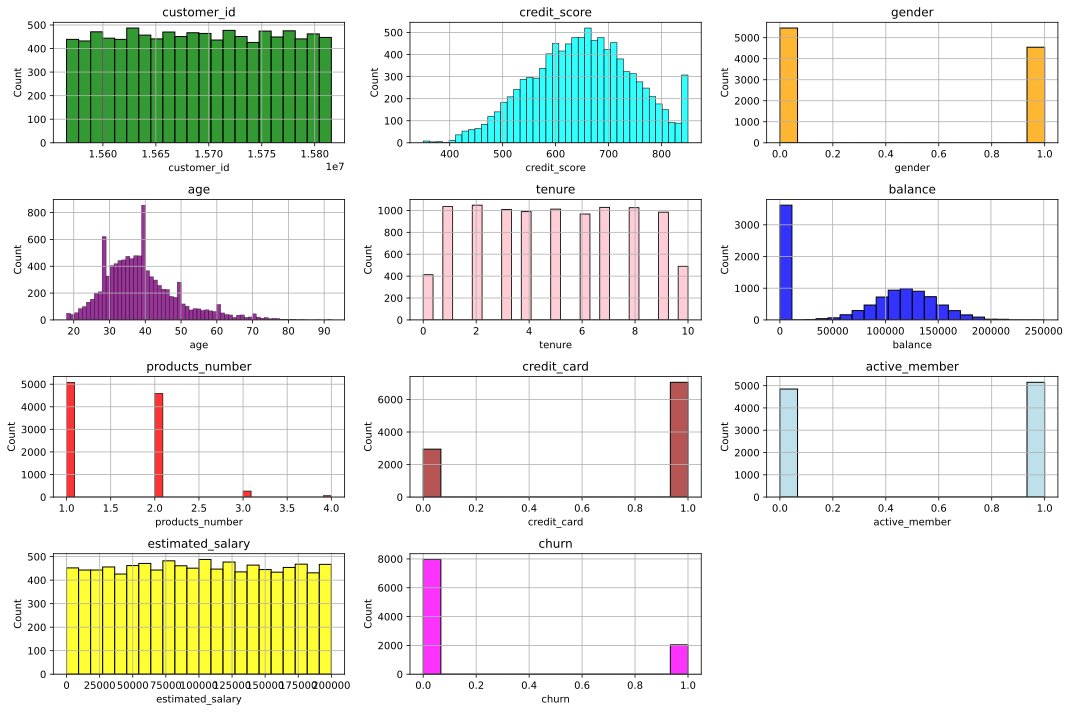

In [15]:
# viz = cdf
# viz.hist()
# plt.show()

#Pretty-fying the histogram:
colors = ['green', 'cyan', 'orange', 'purple','pink','blue','red',
         'brown','lightblue','yellow','magenta','black']
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()
for i, variable in enumerate(cdf.columns):
    color = colors[i]
    sns.histplot(cdf[variable], ax=axes[i],alpha=0.8, color=color)
    axes[i].set_title(variable)
    axes[i].grid(True)
axes[len(cdf.columns)].set_visible(False)
fig.tight_layout()
plt.show()

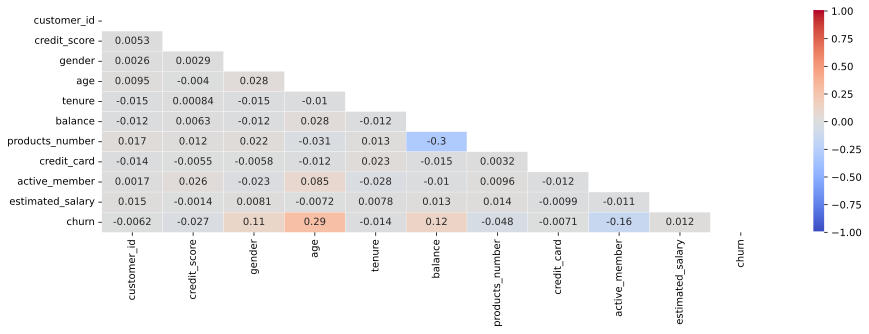

In [16]:
plt.figure(figsize=(15, 4))
corr = cdf.corr(numeric_only=True)
mask = np.triu(np.ones_like(cdf.corr())) 
dataplot = sns.heatmap(corr, annot=True, linewidths=.2, 
                        xticklabels=corr.columns,
                        yticklabels=corr.columns,
                       cmap = 'coolwarm', mask=mask,
                        vmin=-1, vmax=1)

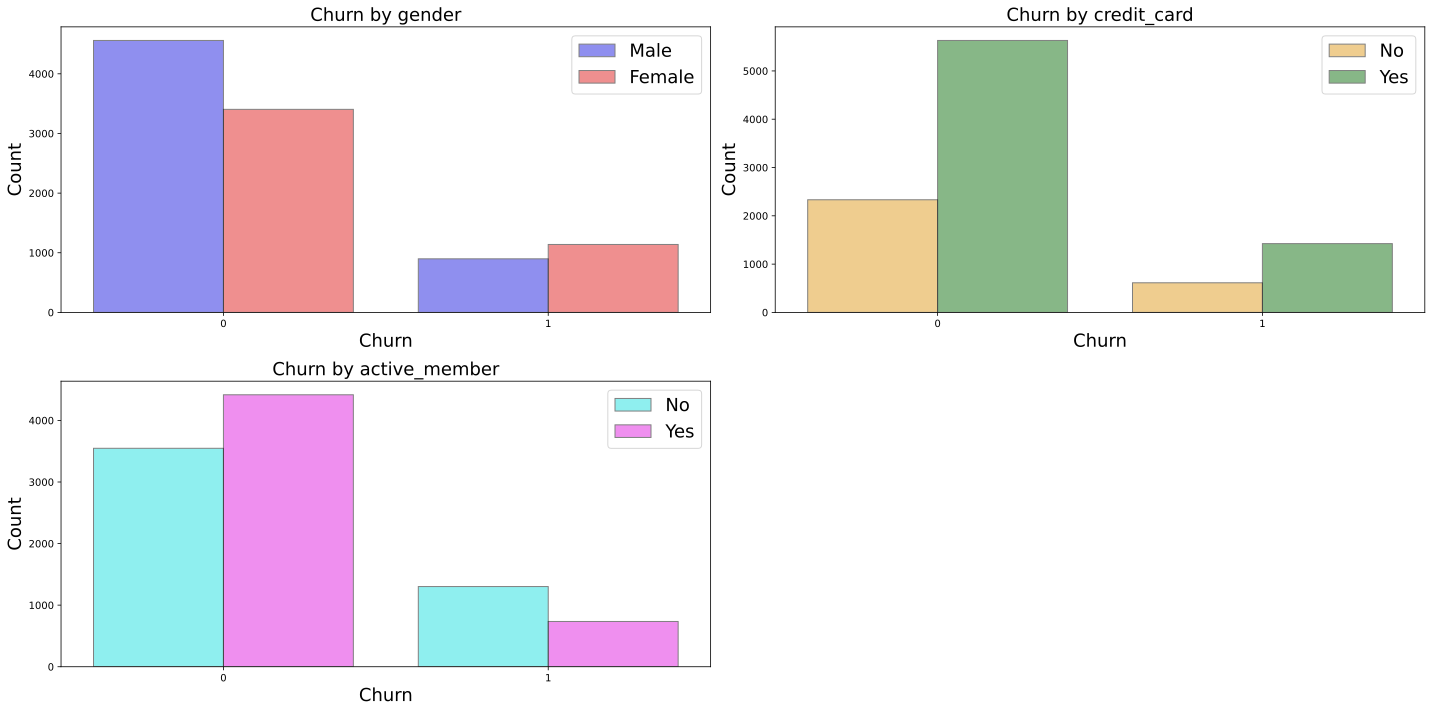

In [17]:
hue_labels = [['Male', 'Female'], ['No', 'Yes'],['No','Yes']]
fig,ax = plt.subplots(2,2, figsize=(20,10))
ax = ax.flatten()
labels = ['gender','credit_card','active_member'];colors = [['blue', 'red'], ['orange','green'],['cyan','magenta']];
for i in range(3):
    palette = colors[i]
    sns.countplot(x='churn', hue=labels[i], data=cdf, palette=palette,
                  edgecolor='black', linewidth=1, ax=ax[i],alpha=0.5)
    ax[i].set_title('Churn by '+labels[i],size=18)
    ax[i].legend(labels=hue_labels[i],
                prop={'size':18})
    ax[i].set_xlabel('Churn',size=18)
    ax[i].set_ylabel('Count',size=18)
ax[3].set_visible(False)
plt.tight_layout()
plt.show()

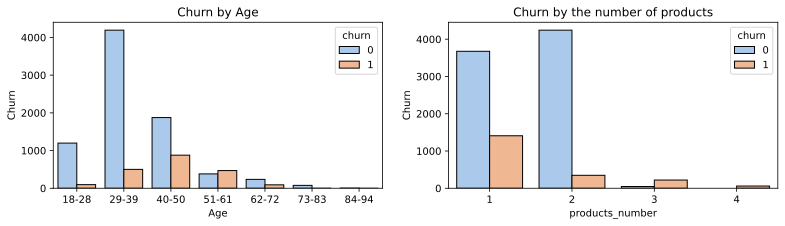

In [18]:
figs,axes = plt.subplots(1,2, figsize=(13,3))

bins = range(min(df.age),max(df.age) + 11,11)
labels = [f'{bins[i]}-{bins[i+1]-1}' for i in range(len(bins)-1)]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

sns.countplot(x='age_group', hue='churn', data=df, ax=axes[0], palette='pastel', edgecolor='black', linewidth=1)
axes[0].set_title('Churn by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Churn')

sns.countplot(x='products_number',hue='churn',data=df, ax=axes[1], palette='pastel',edgecolor='black', linewidth=1)
axes[1].set_title('Churn by the number of products')
axes[1].set_xlabel('products_number')
axes[1].set_ylabel('Churn')

plt.show()

##### $\textit{Clearly product number(1) has the most churn(1), and ages between 29 to 61 include the most churn.}$

# Classification:

## KNN

In [22]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import log_loss

In [23]:
cdf.columns

Index(['customer_id', 'credit_score', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [24]:
X = cdf[['credit_score', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary']].values  #.astype(float)
y = cdf['churn'].values
X[0:2]

array([[6.1900000e+02, 1.0000000e+00, 4.2000000e+01, 2.0000000e+00,
        0.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0134888e+05],
       [6.0800000e+02, 1.0000000e+00, 4.1000000e+01, 1.0000000e+00,
        8.3807860e+04, 1.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        1.1254258e+05]])

In [25]:
scalar = preprocessing.StandardScaler().fit(X)
X = scalar.transform(X.astype(float))

In [26]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (8000, 9) (8000,)
Test set: (2000, 9) (2000,)


In [27]:
k = 6
neigh6 = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
yhat6 = neigh6.predict(X_test)
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh6.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat6))

Train set Accuracy:  0.861375
Test set Accuracy:  0.8335


In [28]:
Ks = 20
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))
# num=[]
for n in range(1,Ks):
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)
    std_acc[n-1]=np.std(yhat==y_test)/np.sqrt(yhat.shape[0])
    num = range(1,Ks)
    
#For the best k number
ult_k = mean_acc.argmax()+1 
knn = KNeighborsClassifier(n_neighbors = ult_k)
neigh_ult = knn.fit(X_train, y_train)
# neigh_ult = KNeighborsClassifier(n_neighbors = ult_k).fit(X_train,y_train)
yhat_ult = neigh_ult.predict(X_test)
print("Train set Accuracy for K = "+str(ult_k)+" is "+ str(metrics.accuracy_score(y_train, neigh_ult.predict(X_train))))
print("Test set Accuracy for K = "+str(ult_k)+" is "+ str(metrics.accuracy_score(y_test, yhat_ult)))

Train set Accuracy for K = 15 is 0.847375
Test set Accuracy for K = 15 is 0.85


In [29]:
churn_pred_knn = neigh_ult.predict(X)
print("Accuracy for K = "+str(ult_k)+" is "+ str(metrics.accuracy_score(y, churn_pred_knn)))

Accuracy for K = 15 is 0.8479


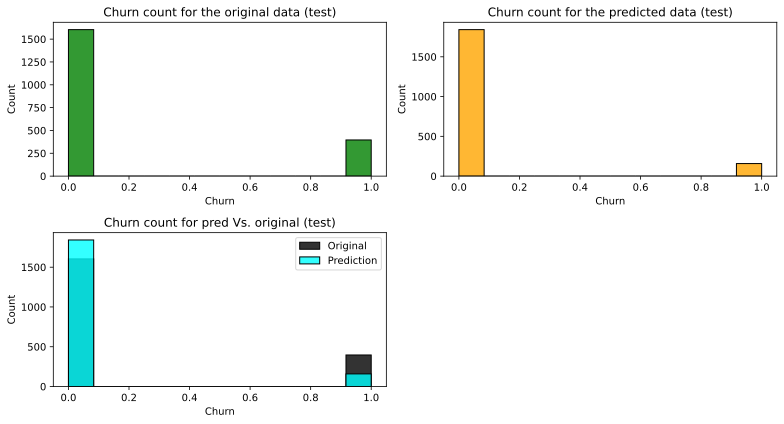

In [30]:
figs,axes = plt.subplots(2,2, figsize=(11,6))

sns.histplot(y_test,alpha=0.8,ax=axes[0,0], color='green')
axes[0,0].set_title('Churn count for the original data (test)')
sns.histplot(yhat_ult,alpha=0.8,ax=axes[0,1], color='orange')
axes[0,1].set_title('Churn count for the predicted data (test)')

sns.histplot(y_test,alpha=0.8, ax=axes[1,0],color='black',label='Original')
sns.histplot(yhat_ult,alpha=0.8, ax=axes[1,0], color='cyan',label='Prediction')
axes[1,0].legend()
axes[1,0].set_title('Churn count for pred Vs. original (test)')
for i in range(2):
    for j in range(2):
        axes[i, j].set_xlabel('Churn')
axes[1, 1].set_visible(False)
plt.tight_layout()
plt.show()

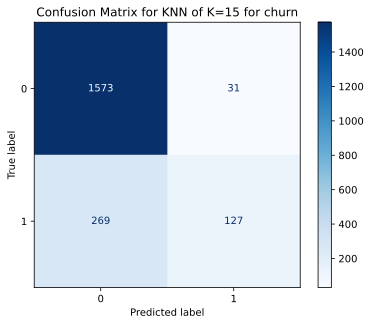

In [31]:
cm_knn = confusion_matrix(y_test, yhat_ult, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for KNN of K='+str(ult_k)+' for churn')
plt.show()

In [32]:
print('The f1 score for KNN with K='+str(ult_k)+' is: ',f1_score(y_test, yhat_ult, average='weighted')),
print('The Jaccard score for KNN with K='+str(ult_k)+' is: ',jaccard_score(y_test, yhat_ult,pos_label=0))

The f1 score for KNN with K=15 is:  0.8229597021398745
The Jaccard score for KNN with K=15 is:  0.8398291510945008


In [33]:
# from mlxtend.plotting import plot_decision_regions
# fig, ax = plt.subplots()
# feature_values = {i: 1 for i in range(1, 9)}
# plot_decision_regions(X_train, y_train, clf=neigh_ult,
#                       filler_feature_values=feature_values,
#                       filler_feature_ranges=feature_values,
#                       legend=2, ax=ax)
# plt.ylim(0,1.5)
# plt.xlabel('X')  
# plt.ylabel('Churn')
# plt.title('KNN with K=' + str(ult_k))
# plt.show()

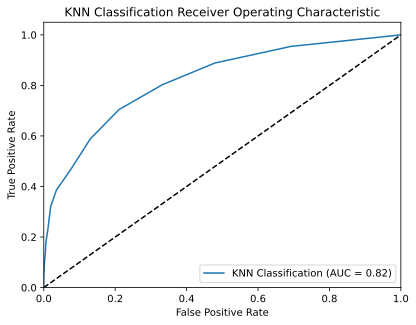

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_prob = knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label='KNN Classification (AUC = %0.2f)' % roc_auc_score(y_test, y_pred_prob))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN Classification Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
from  io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
clf_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
clf_tree.fit(X_train,y_train)
y_pred_tree = clf_tree.predict(X_test)
print (y_pred_tree[0:5])
print (y_test[0:5])

[0 0 0 0 0]
[0 0 0 1 0]


In [38]:
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_pred_tree))

DecisionTrees's Accuracy:  0.8525


##### $\textit{DT's accuracy here is better than KNN's with a K=15.}$

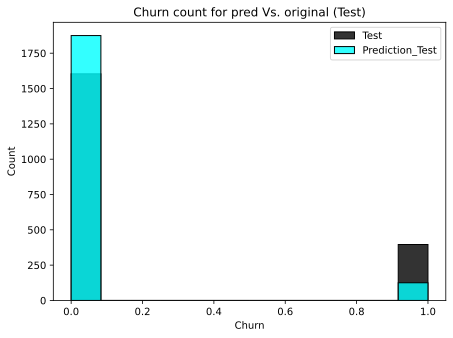

In [40]:
sns.histplot(y_test,alpha=0.8,color='black',label='Test')
sns.histplot(y_pred_tree,alpha=0.8, color='cyan',label='Prediction_Test')
plt.legend()
plt.title('Churn count for pred Vs. original (Test)')
plt.xlabel('Churn')
plt.tight_layout()
plt.show()

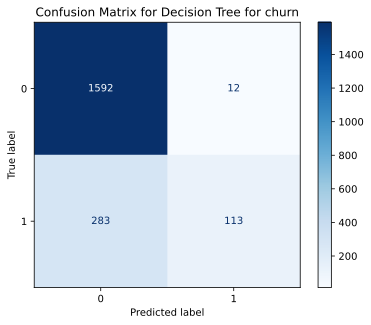

In [41]:
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=clf_tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree,
                              display_labels=clf_tree.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree for churn')
plt.show()

In [42]:
print('The f1 score for Decision Tree is: ',f1_score(y_test, y_pred_tree, average='weighted')),
print('The Jaccard score for Decision Tree is: ',jaccard_score(y_test, y_pred_tree,pos_label=0))
# print('The LogLoss score for Decision Tree is: ',log_loss(y_test, y_pred_tree))

The f1 score for Decision Tree is:  0.8198835017232543
The Jaccard score for Decision Tree is:  0.8436671966083731


In [51]:
print ('The ultimate scores for the Decision Tree are:\n\n',classification_report(y_test, y_pred_tree))

The ultimate scores for the Decision Tree are:

               precision    recall  f1-score   support

           0       0.85      0.99      0.92      1604
           1       0.90      0.29      0.43       396

    accuracy                           0.85      2000
   macro avg       0.88      0.64      0.67      2000
weighted avg       0.86      0.85      0.82      2000



In [53]:
# dot_data = StringIO()
# filename = "churn_tree.png"
# featureNames = ['credit_score', 'gender', 'age', 'tenure', 'balance',
#        'products_number', 'credit_card', 'active_member', 'estimated_salary']
# out=tree.export_graphviz(clf,feature_names=featureNames, out_file=dot_data, class_names= np.unique(y_train), filled=True,  
#                          special_characters=True,rotate=False)  
# graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
# graph.write_png(filename)
# img = mpimg.imread(filename)
# plt.figure(figsize=(100, 200))
# plt.imshow(img,interpolation='nearest')
# # plt.show()

In [132]:
members = cdf[['credit_score', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary']]
set(members)

{'active_member',
 'age',
 'balance',
 'credit_card',
 'credit_score',
 'estimated_salary',
 'gender',
 'products_number',
 'tenure'}

In [148]:
from scipy.stats import entropy

def information_gain(member_series, split):
    # Calculate the entropy before the split
    entropy_before = entropy(member_series.value_counts(normalize=True))

    # Set names for clarity
    split.name = 'split'
    member_series.name = 'member'

    # Group by the split and get the normalized value counts
    grouped_distrib = member_series.groupby(split).value_counts(normalize=True).reset_index(name='count')

    # Pivot the table to get the distribution
    pivot_table = grouped_distrib.pivot_table(index='split', columns='member', values='count', fill_value=0)

    # Calculate the entropy after the split
    entropy_after = entropy(pivot_table.values, axis=1)  # Ensure to get values for entropy calculation
    entropy_after *= split.value_counts(sort=False, normalize=True)  # Weight by the original distribution

    # Return the information gain
    return entropy_before - entropy_after.sum()

members = cdf[['credit_score', 'gender', 'age', 'tenure', 'balance', 
                'products_number', 'credit_card', 'active_member', 'estimated_salary']]
split = cdf['churn']

# Calculate information gain for each individual column in members
for column in members.columns:
    info_gain = information_gain(members[column], split)
    print(f"Information Gain for {column}: {info_gain}")


Information Gain for credit_score: 0.047794119373978816
Information Gain for gender: 0.003553711894696554
Information Gain for age: 0.01728768240144607
Information Gain for tenure: -0.002002332820465469
Information Gain for balance: 0.20574498722411594
Information Gain for products_number: -0.036069109472417704
Information Gain for credit_card: -0.004101933174667893
Information Gain for active_member: 0.03201879213422265
Information Gain for estimated_salary: 1.3132939412397429


## Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import jaccard_score
from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import log_loss

In [58]:
X = cdf[['credit_score', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary']].values  #.astype(float)
y = cdf['churn'].values
X[0:2]

array([[6.1900000e+02, 1.0000000e+00, 4.2000000e+01, 2.0000000e+00,
        0.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        1.0134888e+05],
       [6.0800000e+02, 1.0000000e+00, 4.1000000e+01, 1.0000000e+00,
        8.3807860e+04, 1.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        1.1254258e+05]])

In [60]:
scaler_log = preprocessing.StandardScaler()
X_log = scaler_log.fit(X).transform(X)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (8000, 9) (8000,)
Test set: (2000, 9) (2000,)


In [64]:
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,y_train) #LR model
yhat = LR.predict(X_test) #prediction set of data
yhat_prob = LR.predict_proba(X_test) #probability set of the predictions of churn
yhat_prob[0:10]

array([[0.80643211, 0.19356789],
       [0.82158806, 0.17841194],
       [0.90300251, 0.09699749],
       [0.82841721, 0.17158279],
       [0.88659471, 0.11340529],
       [0.86480573, 0.13519427],
       [0.90520714, 0.09479286],
       [0.74407359, 0.25592641],
       [0.78638991, 0.21361009],
       [0.78681252, 0.21318748]])

In [66]:
jaccard_score(y_test, yhat,pos_label=0)

0.8092783505154639

In [68]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[  60  336]
 [  34 1570]]


Confusion matrix, without normalization
[[  60  336]
 [  34 1570]]


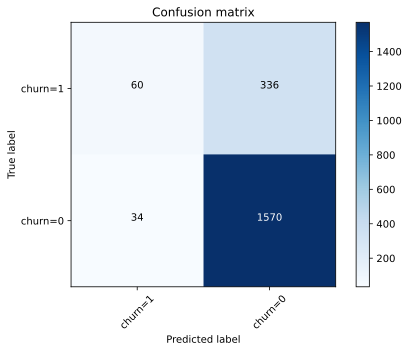

In [70]:
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')
plt.show()

In [71]:
print (classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1604
           1       0.64      0.15      0.24       396

    accuracy                           0.81      2000
   macro avg       0.73      0.57      0.57      2000
weighted avg       0.79      0.81      0.77      2000



In [74]:
log_loss(y_test, yhat_prob)

0.43362383583521535

In [76]:
LR2 = LogisticRegression(C=0.01, solver='sag').fit(X_train,y_train)
yhat_prob2 = LR2.predict_proba(X_test)
print ("LogLoss: : %.2f" % log_loss(y_test, yhat_prob2))

LogLoss: : 0.43


## SVM

In [79]:
import pylab as pl
import scipy.optimize as opt
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score
from sklearn.metrics import jaccard_score

In [81]:
cdf

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,1,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,1,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,1,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,1,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,1,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,0,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,0,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,1,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,0,42,3,75075.31,2,1,0,92888.52,1


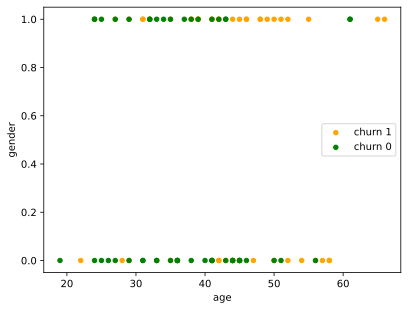

In [83]:
ax = cdf[cdf['churn'] == 1][0:50].plot(kind='scatter', x='age', y='gender', color='orange', label='churn 1');
cdf[cdf['churn'] == 0][0:50].plot(kind='scatter', x='age', y='gender', color='green', label='churn 0', ax=ax);
# plt.ylim(0.999,1.001)
plt.show()

In [84]:
clf_svm = svm.SVC(kernel='rbf')
clf_svm.fit(X_train, y_train) 

SVC()

In [86]:
yhat_svm = clf_svm.predict(X_test)
yhat_svm [0:5]

array([0, 0, 0, 0, 0], dtype=int64)

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1604
           1       0.84      0.38      0.53       396

    accuracy                           0.86      2000
   macro avg       0.85      0.68      0.72      2000
weighted avg       0.86      0.86      0.84      2000

Confusion matrix, without normalization
[[1574   30]
 [ 244  152]]


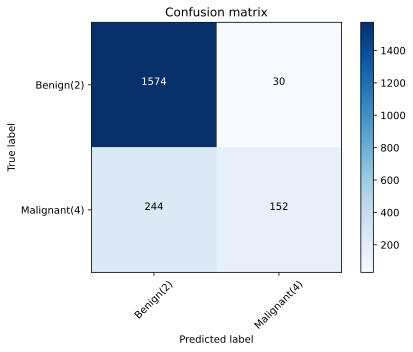

In [87]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat_svm)
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat_svm))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Benign(2)','Malignant(4)'],normalize= False,  title='Confusion matrix')
plt.show()

In [88]:
f1_score(y_test, yhat_svm, average='weighted') 

0.8419221604961991

In [89]:
jaccard_score(y_test, yhat_svm)

0.3568075117370892

In [90]:
clf2 = svm.SVC(kernel='linear')
clf2.fit(X_train, y_train) 
yhat2 = clf2.predict(X_test)
print("Avg F1-score: %.4f" % f1_score(y_test, yhat2, average='weighted'))
print("Jaccard score: %.4f" % jaccard_score(y_test, yhat2))

Avg F1-score: 0.7139
Jaccard score: 0.0000
